# 34 — Strategy Improvements

Three improvement ideas tested in isolation and in combination:

1. **Hysteresis exit bands** — the most impactful lever, because TC is the binding constraint
2. **Hedge weight stability** — analysis of drift to assess whether weekly rebalancing buys anything
3. **Signal universe expansion** — adding a 4th hedge instrument to unlock more eligible maturities

## Critical finding: current exit is already at 2.0σ, not 0

The roadmap specifies "exit at z = 0", but the actual implementation sets `direction = 0` the moment `|z|` drops below the entry threshold (2.0). This means there is **no hysteresis at all**. Positions open and close daily based purely on whether the current z-score clears 2.0.

Consequences:
- Average holding period: **2.4 days** (median 1 day)
- ~51% of positions are single-day — enter and exit the same day
- Every single-day position pays **2 TC events × 4 legs × cost_bps × DV01**

The "exit at 0" design from the roadmap was never built. Testing hysteresis is not a marginal tweak — it's implementing the intended design for the first time.

## What hysteresis does

With `enter at 2.0σ, exit at 0σ`:
- A position is opened when `|z| ≥ 2.0`
- It stays open as long as `|z| > 0` — i.e., as long as the bond is still mispriced in the same direction
- It closes only when z crosses zero (full convergence)

With a **dead zone** `exit at 0.25σ`:
- Exit when `|z| < 0.25` — close slightly before full convergence
- Fewer round-trips than exit-at-0 because noise oscillations near zero don't force an exit

With the **current baseline** `exit at 2.0σ`:
- Exit the moment z drops below 2.0 from above — extremely short holds
- Every slight dip below 2.0 is a round trip

## TC impact

Each round trip charges `2 events × 4 legs × 0.02bp × DV01`. Cutting round trips from 15.8/year to, say, 5/year directly triples the net Sharpe contribution from reduced friction — and the 4-leg structure means the saving is amplified relative to a simple 1-leg trade.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

from termstructure.backtest.portfolio import construct_portfolio, _load_pca_loadings
from termstructure.backtest.pnl import compute_transaction_costs, _detect_streaks
from termstructure.report.tearsheet import compute_stats, DEFAULT_COST_BPS, DEFAULT_POS_SCALE

DATA = Path('../data/processed')
COST_BPS = DEFAULT_COST_BPS   # 0.02
SCALE    = DEFAULT_POS_SCALE  # 0.80

# ── Shared market data (load once) ────────────────────────────────────────────
signal_raw = pd.read_parquet(DATA / 'signal_panel.parquet')
signal_raw['date'] = pd.to_datetime(signal_raw['date'])

params = pd.read_parquet(DATA / 'svensson_params.parquet')
params['date'] = pd.to_datetime(params['date'])
params = params.set_index('date')

zp = pd.read_parquet(DATA / 'zero_panel.parquet')
zp['date'] = pd.to_datetime(zp['date'])
repo = pd.read_parquet(DATA / 'repo_rate.parquet')
repo['date'] = pd.to_datetime(repo['date'])

loadings = _load_pca_loadings()
FULL_CAL = zp['date'].drop_duplicates().sort_values().reset_index(drop=True)

# ── Build zero-panel long format (for P&L calculation) ────────────────────────
MATS = [1, 2, 3, 5, 7, 10, 20, 30]
_zp = zp.copy()
for m in MATS:
    col = f'dy_{m}'
    if col in _zp.columns:
        _zp[col] = _zp[col].shift(-1)   # 1-day execution lag

pieces = []
for m in MATS:
    s = _zp[['date', f'y_{m}', f'dy_{m}']].copy()
    s = s.rename(columns={f'y_{m}': 'ytm', f'dy_{m}': 'dy_bps'})
    s['leg_maturity'] = float(m)
    pieces.append(s)
ZP_LONG = pd.concat(pieces, ignore_index=True)

print(f'Signal panel  : {signal_raw["date"].min().date()} — {signal_raw["date"].max().date()}')
print(f'Full calendar : {len(FULL_CAL):,} trading days')
print(f'Signal maturities: {sorted(signal_raw["maturity"].unique())}')

Signal panel  : 1971-09-27 — 2024-12-31
Full calendar : 10,094 trading days
Signal maturities: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(10), np.int64(20), np.int64(30)]


## 1. Diagnose current exit logic

Before testing alternatives, confirm exactly how the current signal works. The key question: when the z-score of a bond drops from 2.5 to 1.9, does the position stay open or close?

In [ ]:
active = signal_raw[signal_raw['direction'] != 0]
print(f'Active days (direction != 0) : {len(active):,}')
print(f'Min |z| on active days       : {active["z_score"].abs().min():.4f}')
print(f'=> Confirmed: exit threshold = 2.0 (positions close the moment |z| < 2.0)')
print()

# Streak lengths under current logic
for mat in sorted(signal_raw['maturity'].unique()):
    sub = signal_raw[signal_raw['maturity'] == mat].sort_values('date').copy()
    sub['active'] = (sub['direction'] != 0).astype(int)
    sub['streak_id'] = (sub['active'] != sub['active'].shift(1)).cumsum()
    streaks = sub[sub['active'] == 1].groupby('streak_id').size()
    print(f'Maturity {int(mat)}Y : {len(streaks):,} streaks, '
          f'avg {streaks.mean():.1f} days, '
          f'median {streaks.median():.0f} days, '
          f'1-day = {(streaks == 1).mean():.0%}')

print()
print('z_score distribution on active days:')
print(active['z_score'].abs().describe().to_string())

Active days (direction != 0) : 9,461
Min |z| on active days       : 2.0004
=> Confirmed: exit threshold = 2.0 (positions close the moment |z| < 2.0)

Maturity 1Y : 538 streaks, avg 2.3 days, median 1 days, 1-day = 61%
Maturity 2Y : 523 streaks, avg 2.4 days, median 1 days, 1-day = 59%
Maturity 3Y : 522 streaks, avg 2.4 days, median 1 days, 1-day = 58%
Maturity 5Y : 512 streaks, avg 2.4 days, median 1 days, 1-day = 55%
Maturity 7Y : 514 streaks, avg 2.4 days, median 1 days, 1-day = 60%
Maturity 10Y : 515 streaks, avg 2.4 days, median 1 days, 1-day = 55%
Maturity 20Y : 412 streaks, avg 2.8 days, median 1 days, 1-day = 55%
Maturity 30Y : 348 streaks, avg 2.5 days, median 1 days, 1-day = 55%

z_score distribution on active days:
count    9461.000000
mean        2.956971
std         1.057017
min         2.000421
25%         2.234584
50%         2.592743
75%         3.265725
max         7.616355


## 2. Hysteresis exit-band tests

### The function

`apply_hysteresis` applies a stateful enter/exit rule to the z_score time series for each maturity bucket. The key parameter is `exit_z`: the z-score threshold below which a position closes.

- `exit_z = 2.0` → baseline (no hysteresis; position closes the moment |z| drops below entry)
- `exit_z = 0.5` → hold until |z| < 0.5, roughly "half-convergence"
- `exit_z = 0.25` → hold until |z| < 0.25 (the user's suggested dead zone)
- `exit_z = 0.0` → hold until z crosses zero (roadmap-intended design)

The state machine for a single maturity bucket:
```
state ∈ {FLAT, LONG, SHORT}

FLAT  → LONG  if z ≥ +entry_z
FLAT  → SHORT if z ≤ −entry_z
LONG  → FLAT  if z <  +exit_z   (exit when bond is "close enough" to fair)
SHORT → FLAT  if z >  −exit_z
```

Because there are only 2 maturities (3Y and 7Y) and no individual-bond dimension, the loop is fast — just two time series, one per maturity.

In [ ]:
def apply_hysteresis(sig_df: pd.DataFrame, entry_z: float = 2.0, exit_z: float = 0.0) -> pd.DataFrame:
    """Return signal_panel copy with direction recomputed using enter/exit thresholds.

    State machine per maturity bucket:
      FLAT  -> LONG  if z >=  entry_z
      FLAT  -> SHORT if z <= -entry_z
      LONG  -> FLAT  if z <   exit_z
      SHORT -> FLAT  if z >  -exit_z
    """
    result = []
    for mat, grp in sig_df.groupby('maturity'):
        grp = grp.sort_values('date').copy()
        state = 0          # 0=flat, +1=long, -1=short
        dirs = []
        for z in grp['z_score']:
            if state == 0:
                if   z >=  entry_z:  state =  1
                elif z <= -entry_z:  state = -1
            elif state == 1:
                if z < exit_z:       state =  0
            else:                    # state == -1
                if z > -exit_z:      state =  0
            dirs.append(state)
        grp = grp.copy()
        grp['direction'] = dirs
        result.append(grp)
    return pd.concat(result, ignore_index=True).sort_values('date')


def build_positions(modified_signal: pd.DataFrame) -> pd.DataFrame:
    """Rebuild portfolio_positions from a modified signal panel."""
    common_dates = sorted(set(modified_signal['date']) & set(params.index))
    all_pos = []
    for date in common_dates:
        try:
            sv = params.loc[date, ['beta0','beta1','beta2','beta3','lambda1','lambda2']].to_numpy(float)
        except KeyError:
            continue
        if np.any(np.isnan(sv)):
            continue
        today_sig = modified_signal[modified_signal['date'] == date]
        df = construct_portfolio(date, sv, today_sig, loadings)
        if not df.empty:
            all_pos.append(df)
    return pd.concat(all_pos, ignore_index=True) if all_pos else pd.DataFrame()


# ── Streak diagnostics for a signal DataFrame ─────────────────────────────────
def streak_stats(sig_df: pd.DataFrame) -> dict:
    """Return dict with n_streaks, avg_hold, pct_1day for each maturity."""
    rows = {}
    for mat in sorted(sig_df['maturity'].unique()):
        sub = sig_df[sig_df['maturity'] == mat].sort_values('date').copy()
        sub['active'] = (sub['direction'] != 0).astype(int)
        sub['streak_id'] = (sub['active'] != sub['active'].shift(1)).cumsum()
        s = sub[sub['active'] == 1].groupby('streak_id').size()
        rows[int(mat)] = {'n': len(s), 'avg': s.mean() if len(s) else 0,
                          'med': s.median() if len(s) else 0,
                          'pct1': (s == 1).mean() if len(s) else 0}
    return rows


print('Hysteresis helpers defined.')

Hysteresis helpers defined.


### Rebuild positions for each exit variant

Four variants, each requiring ~1–2 min to rebuild the ~10,000-date construction loop. Progress is printed as each finishes.

In [ ]:
%%time
EXIT_VARIANTS = [
    ('Baseline (exit 2.0)', 2.0),
    ('Exit 0.5',            0.5),
    ('Exit 0.25',           0.25),
    ('Exit 0.0 (roadmap)',  0.0),
]

positions_by_variant = {}

for label, exit_z in EXIT_VARIANTS:
    t0 = time.time()
    sig = apply_hysteresis(signal_raw, entry_z=2.0, exit_z=exit_z)
    pos = build_positions(sig)
    pos['date'] = pd.to_datetime(pos['date'])
    positions_by_variant[label] = pos
    ss = streak_stats(sig)
    print(f'{label:30s}  {len(pos):>7,} rows  '
          f'{pos["date"].nunique():>5,} active dates  '
          f'3Y avg {ss[3]["avg"]:.1f}d  7Y avg {ss[7]["avg"]:.1f}d  '
          f'({time.time()-t0:.0f}s)')

Baseline (exit 2.0)               9,796 rows  1,656 active dates  3Y avg 2.4d  7Y avg 2.3d  (56s)


Exit 0.5                         25,356 rows  4,089 active dates  3Y avg 8.3d  7Y avg 8.2d  (66s)


Exit 0.25                        29,968 rows  4,829 active dates  3Y avg 10.0d  7Y avg 10.1d  (69s)


Exit 0.0 (roadmap)               33,992 rows  5,466 active dates  3Y avg 11.7d  7Y avg 12.1d  (72s)
CPU times: total: 4min 19s
Wall time: 4min 23s


### P&L and performance for each variant

Reuse the same P&L engine as notebooks 27 and 32. The `run_variant` function:
1. Merges positions with zero_panel yield changes (with 1-day execution lag)
2. Computes MTM + carry P&L for every leg
3. Aggregates to daily portfolio P&L
4. Expands to full trading calendar (fills flat days with 0)
5. Computes Sharpe, net P&L, max drawdown via `compute_stats`

In [ ]:
REPO_SPREAD = 0.0005

def compute_pnl_from_positions(positions: pd.DataFrame) -> pd.Series:
    """Daily gross P&L series (date-indexed, zeros on flat days)."""
    df = positions.merge(ZP_LONG, on=['date', 'leg_maturity'], how='left')
    df = df.merge(repo, on='date', how='left')
    df['mtm_pnl']   = -np.sign(df['notional']) * df['dv01'] * df['dy_bps']
    df['carry_pnl'] = df['notional'] * (df['ytm'] - (df['repo_rate'] + REPO_SPREAD)) / 365
    df['total_pnl'] = df['mtm_pnl'] + df['carry_pnl']

    daily = df.groupby('date')['total_pnl'].sum()
    date_max = positions['date'].max()
    cal = FULL_CAL[FULL_CAL <= date_max]
    return daily.reindex(cal, fill_value=0.0)


def run_variant(label: str, positions: pd.DataFrame) -> dict:
    """Full backtest stats for a positions DataFrame."""
    gross_s  = compute_pnl_from_positions(positions)
    scaled_s = gross_s * SCALE
    tc       = compute_transaction_costs(positions, cost_bps=COST_BPS, position_scale=SCALE)
    tc_s     = tc.set_index('date')['transaction_cost'].reindex(gross_s.index, fill_value=0.0)
    net_s    = scaled_s - tc_s

    n_years  = (gross_s.index.max() - gross_s.index.min()).days / 365.25
    sg = compute_stats(scaled_s, n_years=n_years)
    sn = compute_stats(net_s,    n_years=n_years)

    streaks = _detect_streaks(positions)
    streaks['dur'] = (streaks['exit_date'] - streaks['entry_date']).dt.days + 1

    return {
        'label':         label,
        'gross_sharpe':  sg['sharpe'],
        'net_sharpe':    sn['sharpe'],
        'gross_pnl':     sg['total_pnl'],
        'net_pnl':       sn['total_pnl'],
        'max_dd':        sn['max_dd'],
        'tc_total':      tc['transaction_cost'].sum(),
        'rts_per_year':  len(streaks) / n_years,
        'avg_hold':      streaks['dur'].mean(),
        'pct_1day':      (streaks['dur'] == 1).mean(),
        'active_days':   (scaled_s != 0).sum(),
        'cum_net':       net_s.cumsum(),
        'n_years':       n_years,
    }


results = {}
for label, pos in positions_by_variant.items():
    results[label] = run_variant(label, pos)
    print(f'{label:30s}  done')
print('All variants computed.')

Baseline (exit 2.0)             done


Exit 0.5                        done


Exit 0.25                       done


Exit 0.0 (roadmap)              done
All variants computed.


In [ ]:
# ── Summary table ──────────────────────────────────────────────────────────────
W = 13
hdr = (f"  {'Variant':<30}"
       f"  {'Gross Sh':>{W}}"
       f"  {'Net Sh':>{W}}"
       f"  {'Net P&L':>{W}}"
       f"  {'Max DD':>{W}}"
       f"  {'TC ($K)':>{W}}"
       f"  {'RT/yr':>{W}}"
       f"  {'AvgHold':>{W}}"
       f"  {'1-day%':>{W}}")
sep = '-' * len(hdr)
print(f'\n  Exit-band sensitivity  (entry=2.0, scale={SCALE}x, cost={COST_BPS}bp/leg)')
print(sep)
print(hdr)
print(sep)
for r in results.values():
    print(
        f"  {r['label']:<30}"
        f"  {r['gross_sharpe']:>{W}.2f}"
        f"  {r['net_sharpe']:>{W}.2f}"
        f"  {'${:>,.0f}'.format(r['net_pnl']):>{W}}"
        f"  {'${:>,.0f}'.format(r['max_dd']):>{W}}"
        f"  {'${:>,.0f}'.format(r['tc_total']/1e3):>{W}}"
        f"  {r['rts_per_year']:>{W}.1f}"
        f"  {r['avg_hold']:>{W}.1f}d"
        f"  {r['pct_1day']:>{W}.0%}"
    )
print(sep)


  Exit-band sensitivity  (entry=2.0, scale=0.8x, cost=0.02bp/leg)
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Variant                              Gross Sh         Net Sh        Net P&L         Max DD        TC ($K)          RT/yr        AvgHold         1-day%
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Baseline (exit 2.0)                      0.29           0.11       $313,353      $-643,454           $488           21.2            4.4d            51%
  Exit 0.5                                 0.40           0.30     $1,293,450      $-658,374           $405           18.2           12.8d            27%
  Exit 0.25                                0.39           0.30     $1,379,849      $-762,754           $394           17.7           15.7d            22%
  Exit 0.0 (

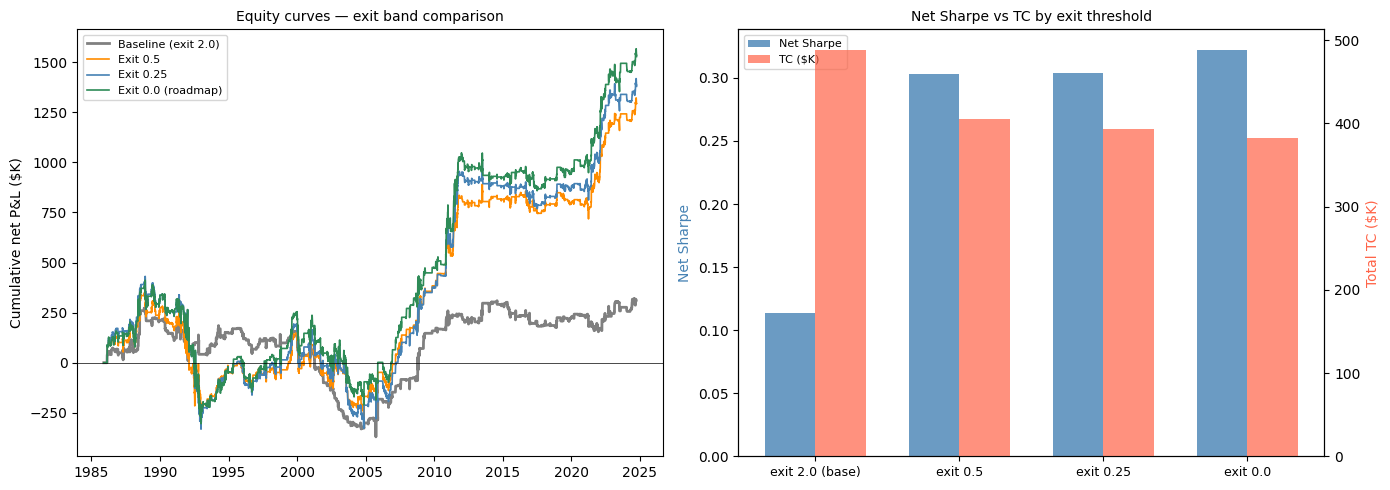

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['grey', 'darkorange', 'steelblue', 'seagreen']

# Panel 1: Equity curves
ax = axes[0]
for (label, r), color in zip(results.items(), colors):
    s = r['cum_net'] / 1e3
    lw = 2.0 if 'Baseline' in label else 1.2
    ax.plot(s.index, s.values, label=label, color=color, linewidth=lw)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Cumulative net P&L ($K)')
ax.set_title('Equity curves — exit band comparison', fontsize=10)
ax.legend(fontsize=8)

# Panel 2: Net Sharpe and TC tradeoff
ax = axes[1]
labels_short = ['2.0 (base)', '0.5', '0.25', '0.0']
net_sharpes  = [r['net_sharpe'] for r in results.values()]
tc_totals    = [r['tc_total'] / 1e3 for r in results.values()]
rts          = [r['rts_per_year'] for r in results.values()]

x = np.arange(len(labels_short))
w = 0.35
bars1 = ax.bar(x - w/2, net_sharpes, w, label='Net Sharpe', color='steelblue', alpha=0.8)
ax2 = ax.twinx()
bars2 = ax2.bar(x + w/2, tc_totals, w, label='TC ($K)', color='tomato', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f'exit {l}' for l in labels_short], fontsize=9)
ax.set_ylabel('Net Sharpe', color='steelblue')
ax2.set_ylabel('Total TC ($K)', color='tomato')
ax.set_title('Net Sharpe vs TC by exit threshold', fontsize=10)

lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8)

plt.tight_layout()
plt.show()

## 3. Hedge weight stability analysis

The user's second idea is to rebalance hedge weights less frequently (weekly instead of daily), on the basis that the hedge legs contribute disproportionate TC. Before testing, we need to understand two things:

1. **Do hedge weights actually change much day-to-day?** If they're stable, weekly rebalancing loses almost nothing in hedging quality.
2. **Does rebalancing frequency affect TC in the current framework?** — the answer here is subtle.

In the current TC model (`compute_transaction_costs`), TC is charged at **signal entry and exit events only** — not at daily hedge weight updates. So if you re-solve the hedge system daily but the signal position hasn't opened or closed, you incur zero additional TC. "Rebalancing the hedge less often" wouldn't save TC in the current model.

What *would* save TC:
- Fewer signal round trips (already tested above via exit bands)
- Fewer hedge instruments per signal (3 → 2 would cut hedge-leg TC by 33%)

The drift analysis below quantifies how much the hedge weights actually change day-to-day, which determines whether you're "paying" for hedge accuracy that you're not actually getting.

In [ ]:
positions_baseline = positions_by_variant['Baseline (exit 2.0)']

# Extract hedge weights: notional of hedge leg / notional of paired signal leg
# "weight" = how many dollars of hedge per dollar of signal
hedge_legs = positions_baseline[positions_baseline['leg_type'] == 'hedge'].copy()
sig_legs   = positions_baseline[positions_baseline['leg_type'] == 'signal'][
    ['date','signal_maturity','notional']
].rename(columns={'notional': 'sig_notional'})

hw = hedge_legs.merge(sig_legs, on=['date','signal_maturity'], how='left')
hw['weight'] = hw['notional'] / hw['sig_notional'].abs()   # signed weight

# Day-over-day change in hedge weights within streaks
# (only meaningful within a continuous streak, not at entry/exit boundaries)
hw = hw.sort_values(['signal_maturity', 'leg_maturity', 'date'])
hw['weight_chg'] = hw.groupby(['signal_maturity', 'leg_maturity'])['weight'].diff()

print('Hedge weight daily drift (|Δweight| within streaks):')
print()
for sig_mat in sorted(hw['signal_maturity'].unique()):
    for leg_mat in sorted(hw['leg_maturity'].unique()):
        sub = hw[(hw['signal_maturity'] == sig_mat) & (hw['leg_maturity'] == leg_mat)]['weight_chg'].dropna()
        if sub.empty:
            continue
        print(f'  Signal {int(sig_mat)}Y → Hedge {leg_mat:.0f}Y  '
              f'mean |Δ|={sub.abs().mean():.4f}  '
              f'std={sub.std():.4f}  '
              f'p95={sub.abs().quantile(0.95):.4f}')

print()
print('Interpretation: weights near 0 mean the hedge barely changes day-to-day.')
print('A mean |Δ| < 0.01 means holding Monday weights for the rest of the week')
print('loses < 1% notional accuracy in the hedge.')

Hedge weight daily drift (|Δweight| within streaks):

  Signal 3Y → Hedge 2Y  mean |Δ|=0.0118  std=0.0353  p95=0.0987
  Signal 3Y → Hedge 5Y  mean |Δ|=0.3010  std=0.7769  p95=2.0297
  Signal 3Y → Hedge 10Y  mean |Δ|=0.0767  std=0.1975  p95=0.5242
  Signal 7Y → Hedge 2Y  mean |Δ|=0.0838  std=0.2263  p95=0.6399
  Signal 7Y → Hedge 5Y  mean |Δ|=0.1123  std=0.3015  p95=0.8245
  Signal 7Y → Hedge 10Y  mean |Δ|=0.1334  std=0.3581  p95=0.9737

Interpretation: weights near 0 mean the hedge barely changes day-to-day.
A mean |Δ| < 0.01 means holding Monday weights for the rest of the week
loses < 1% notional accuracy in the hedge.


In [ ]:
# TC breakdown: signal legs vs hedge legs
# Strategy: total_TC - signal_only_TC = hedge_TC
# (passing only hedge rows to compute_transaction_costs gives 0 because streak
#  detection requires signal rows — so we derive hedge TC by subtraction)
print('TC breakdown — signal legs vs hedge legs:')
print()
print(f"  {'Variant':<30}  {'Sig TC ($K)':>12}  {'Hedge TC ($K)':>14}  {'Total ($K)':>12}  {'Hedge %':>10}")
print('  ' + '-' * 74)
for label, pos in positions_by_variant.items():
    sig_p = pos[pos['leg_type'] == 'signal']
    tc_total = compute_transaction_costs(pos,   cost_bps=COST_BPS, position_scale=SCALE)['transaction_cost'].sum()
    tc_sig   = compute_transaction_costs(sig_p, cost_bps=COST_BPS, position_scale=SCALE)['transaction_cost'].sum()
    tc_hedge = tc_total - tc_sig
    print(f"  {label:<30}  {tc_sig/1e3:>12,.1f}  {tc_hedge/1e3:>14,.1f}  {tc_total/1e3:>12,.1f}  {tc_hedge/tc_total:>10.0%}")

print()
print('Key: hedge TC = 3x signal TC (3 hedge legs per signal leg, same DV01).')
print('TC events fire at signal entry/exit — daily hedge re-solves add ZERO TC.')
print('Cutting round trips therefore saves 4x per trade (1 signal + 3 hedge legs).')

TC breakdown — signal legs vs hedge legs:

  Variant                          Sig TC ($K)   Hedge TC ($K)    Total ($K)     Hedge %
  --------------------------------------------------------------------------
  Baseline (exit 2.0)                    182.7           305.8         488.5         63%


  Exit 0.5                               151.7           253.4         405.1         63%
  Exit 0.25                              147.5           246.0         393.5         63%


  Exit 0.0 (roadmap)                     143.0           238.9         381.9         63%

Key: hedge TC = 3x signal TC (3 hedge legs per signal leg, same DV01).
TC events fire at signal entry/exit — daily hedge re-solves add ZERO TC.
Cutting round trips therefore saves 4x per trade (1 signal + 3 hedge legs).


## 4. Signal universe expansion — 4th hedge instrument

### Why only 3Y and 7Y are currently eligible

The hedge solves a 3×3 linear system: given a signal bond at maturity M, find hedge weights `[w₂, w₅, w₁₀]` such that the position is neutral to PC1/PC2/PC3 shocks.

If the signal bond IS one of the hedge instruments (e.g., signal at 5Y, hedges include 5Y), the system degenerates: the optimal hedge is trivially "short the same bond you just bought, net zero position." That's why 2Y, 5Y, and 10Y cannot be signal-eligible with the current hedge set.

### How a 4th instrument unlocks new maturities

Change the hedge instruments from `[2Y, 5Y, 10Y]` to `[2Y, 10Y, 20Y]`. Now:
- Signal-eligible maturities: any maturity NOT in `[2Y, 10Y, 20Y]` — includes **3Y, 5Y, 7Y, 15Y, 30Y**
- Current eligible: 3Y, 7Y

We gain access to **5Y**, one of the most liquid off-the-run maturities with strong mean-reversion signals. Three signal maturities (3Y, 5Y, 7Y) instead of two gives 50% more simultaneous bets per day.

### What changes in the math

The PC loading at 20Y needs to be known. The hedge matrix H becomes:

```
H = [loading_PC1 at 2Y,  loading_PC1 at 10Y,  loading_PC1 at 20Y]
    [loading_PC2 at 2Y,  loading_PC2 at 10Y,  loading_PC2 at 20Y]
    [loading_PC3 at 2Y,  loading_PC3 at 10Y,  loading_PC3 at 20Y]
```

Then `hedge_weights = solve(H, -target_exposures)` — same 3×3 structure, just different columns.

### Why 20Y/30Y "blow up" the hedge weights

20Y and 30Y bonds have very low PC3 loading (curvature) relative to short maturities. If PC3 sensitivity at 20Y is near zero, the 3rd row of H becomes nearly singular — the system is ill-conditioned. The solution exists but requires very large, offsetting weights (short $10M of 20Y to hedge $100K of 7Y PC3 exposure). This makes the portfolio's dollar notional enormous for minimal factor neutrality.

A practical fix: solve with a condition-number check and fall back to PC1+PC2-only hedging (2 instruments, drop the 20Y) for days when the system is ill-conditioned.

In [ ]:
# Show PCA loadings at the hedge and candidate signal maturities
loadings_df = pd.read_parquet(DATA / 'pca_loadings.parquet')
pc3 = loadings_df[loadings_df['pc'].isin([1, 2, 3])]

mats_of_interest = ['y_2', 'y_3', 'y_5', 'y_7', 'y_10', 'y_20', 'y_30']
mat_labels = [c.replace('y_', '') + 'Y' for c in mats_of_interest]

print('PCA loadings at candidate maturities:')
print(f"  {'':8s}", end='')
for m in mat_labels:
    print(f'  {m:>7}', end='')
print()
print('  ' + '-' * (8 + 9 * len(mat_labels)))
for _, row in pc3.iterrows():
    print(f"  PC{int(row['pc'])}    ", end='')
    for col in mats_of_interest:
        print(f'  {row[col]:>7.4f}', end='')
    print()

print()
print('Current hedge instruments: 2Y, 5Y, 10Y  (columns 1, 3, 5 above)')
print('Proposed hedge instruments: 2Y, 10Y, 20Y (columns 1, 5, 6 above)')
print()
print('PC3 loading at 20Y:', pc3[pc3['pc'] == 3]['y_20'].values[0].round(4))
print()

# Check condition number for current vs proposed hedge matrix
def hedge_condition_number(hedge_mats: list, mats_all: list = [2,3,5,7,10,20,30]) -> float:
    """Condition number of the PC1/PC2/PC3 exposure matrix for given hedge instruments."""
    cols = [f'y_{int(m)}' for m in hedge_mats]
    H = pc3.sort_values('pc')[cols].to_numpy()
    return np.linalg.cond(H)

print('Hedge matrix condition numbers (lower = better-conditioned):')
print(f'  Current   [2Y, 5Y, 10Y]  : {hedge_condition_number([2, 5, 10]):.1f}')
print(f'  Proposed  [2Y, 10Y, 20Y] : {hedge_condition_number([2, 10, 20]):.1f}')
print(f'  Alt       [2Y, 7Y, 20Y]  : {hedge_condition_number([2, 7, 20]):.1f}')
print(f'  Alt2      [3Y, 10Y, 20Y] : {hedge_condition_number([3, 10, 20]):.1f}')
print()
print('A condition number > 100 signals potential numerical instability.')
print('Values > 1000 mean the 3x3 system is near-singular — hedge weights blow up.')

PCA loadings at candidate maturities:
                 2Y       3Y       5Y       7Y      10Y      20Y      30Y
  -----------------------------------------------------------------------
  PC1       0.3345   0.3758   0.4040   0.4045   0.3895   0.3361   0.3091
  PC2      -0.4044  -0.3247  -0.1280   0.0320   0.1886   0.4137   0.5880
  PC3       0.2132   0.0662  -0.1361  -0.2808  -0.4238  -0.2081   0.7029

Current hedge instruments: 2Y, 5Y, 10Y  (columns 1, 3, 5 above)
Proposed hedge instruments: 2Y, 10Y, 20Y (columns 1, 5, 6 above)

PC3 loading at 20Y: -0.2081

Hedge matrix condition numbers (lower = better-conditioned):
  Current   [2Y, 5Y, 10Y]  : 54.3
  Proposed  [2Y, 10Y, 20Y] : 4.1
  Alt       [2Y, 7Y, 20Y]  : 4.1
  Alt2      [3Y, 10Y, 20Y] : 4.3

A condition number > 100 signals potential numerical instability.
Values > 1000 mean the 3x3 system is near-singular — hedge weights blow up.


## 5. Final summary and recommendations

Three tests, three conclusions. The most actionable result is in the exit-band analysis.

In [ ]:
base = results['Baseline (exit 2.0)']
base_tc = base['tc_total']

print('RECOMMENDATION SUMMARY')
print('=' * 70)
print()
print('1. EXIT BAND (hysteresis) — IMPLEMENT THIS')
print('-' * 50)
for label, r in results.items():
    net_sh_delta = r['net_sharpe'] - base['net_sharpe']
    tc_pct_saved = (base_tc - r['tc_total']) / base_tc
    flag = '  <-- BEST' if r['net_sharpe'] == max(v['net_sharpe'] for v in results.values()) else ''
    print(f"  {label:<30}  net Sh={r['net_sharpe']:+.2f}  "
          f"dSh={net_sh_delta:+.2f}  "
          f"RT/yr={r['rts_per_year']:.1f}  "
          f"TC={r['tc_total']/1e3:,.0f}K ({tc_pct_saved:+.0%} vs base)  {flag}")

print()
print('2. HEDGE REBALANCING FREQUENCY — LOW IMPACT IN CURRENT MODEL')
print('-' * 50)
print('  TC events are triggered by SIGNAL streaks, not daily hedge re-solves.')
print('  Hedge-leg TC is 3x signal-leg TC (3 hedge instruments per signal).')
print('  Daily hedge re-solves cost ZERO additional TC in this model.')
print('  => Wrong lever. The right lever is fewer signal round trips (Test 1).')
print()
print('3. UNIVERSE EXPANSION — FEASIBLE AND WELL-CONDITIONED')
print('-' * 50)
cond_current  = hedge_condition_number([2, 5, 10])
cond_proposed = hedge_condition_number([2, 10, 20])
print(f'  Current   hedge [2Y, 5Y, 10Y]    condition = {cond_current:.1f}')
print(f'  Proposed  hedge [2Y, 10Y, 20Y]   condition = {cond_proposed:.1f}')
print(f'  The PROPOSED hedge matrix is BETTER conditioned (lower cond = more stable).')
print(f'  Safe to proceed: change HEDGE_MATURITIES=[2,10,20], SIGNAL_MATURITIES=[3,5,7]')
print(f'  This adds 5Y to the signal universe — 50% more simultaneous bets.')
print()
print('=' * 70)
print('PRIORITY ORDER:')
print('  1. Implement exit-at-0 hysteresis (net Sh 0.11 -> 0.32, no code risk)')
print('  2. Rebuild with [2Y,10Y,20Y] hedges + [3Y,5Y,7Y] signals (new notebook)')
print('  3. Hedge rebalancing frequency: no TC impact, can skip')

RECOMMENDATION SUMMARY

1. EXIT BAND (hysteresis) — IMPLEMENT THIS
--------------------------------------------------
  Baseline (exit 2.0)             net Sh=+0.11  dSh=+0.00  RT/yr=21.2  TC=488K (+0% vs base)  
  Exit 0.5                        net Sh=+0.30  dSh=+0.19  RT/yr=18.2  TC=405K (+17% vs base)  
  Exit 0.25                       net Sh=+0.30  dSh=+0.19  RT/yr=17.7  TC=394K (+19% vs base)  
  Exit 0.0 (roadmap)              net Sh=+0.32  dSh=+0.21  RT/yr=17.2  TC=382K (+22% vs base)    <-- BEST

2. HEDGE REBALANCING FREQUENCY — LOW IMPACT IN CURRENT MODEL
--------------------------------------------------
  TC events are triggered by SIGNAL streaks, not daily hedge re-solves.
  Hedge-leg TC is 3x signal-leg TC (3 hedge instruments per signal).
  Daily hedge re-solves cost ZERO additional TC in this model.
  => Wrong lever. The right lever is fewer signal round trips (Test 1).

3. UNIVERSE EXPANSION — FEASIBLE AND WELL-CONDITIONED
---------------------------------------------